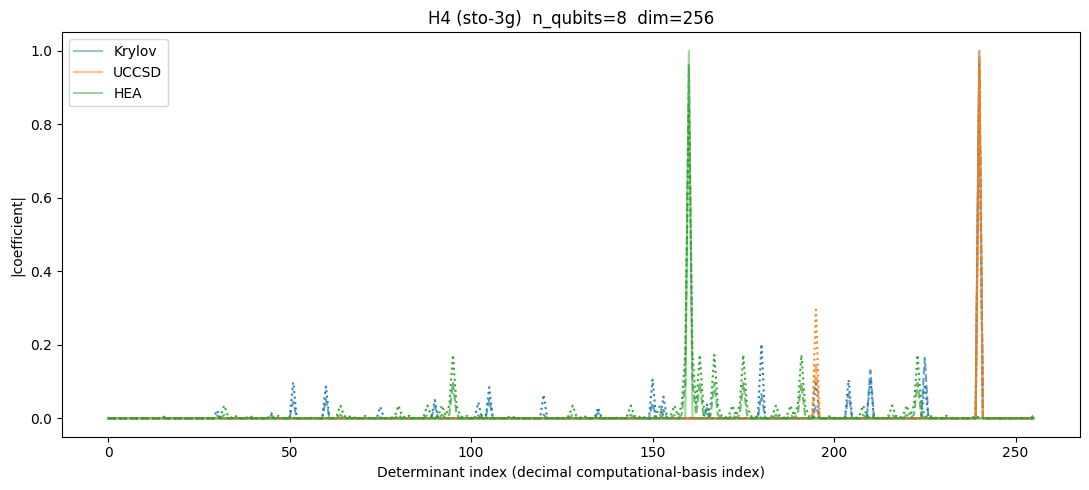

In [1]:
import pennylane as qml
from pennylane import numpy as np
import numpy as onp
import matplotlib.pyplot as plt

# ============================================================
# 1) Build Hamiltonian + HF
# ============================================================
def build_hamiltonian(mol_name: str, bond_length: float = 0.74, basis: str = "sto-3g"):
    """
    Supports: "H2", "H4", "LIH", "H2O"
    Returns: (H, n_qubits, electrons, hf_bitstring)
    """
    name = mol_name.strip().upper()

    if name == "H2":
        symbols = ["H", "H"]
        geometry = np.array([[0.0, 0.0, 0.0],
                             [0.0, 0.0, bond_length]], dtype=float)
        electrons = 2
        charge = 0
        mult = 1

    elif name == "H4":
        symbols = ["H", "H", "H", "H"]
        geometry = np.array([[0.0, 0.0, 0.0],
                             [0.0, 0.0, bond_length],
                             [0.0, 0.0, 2 * bond_length],
                             [0.0, 0.0, 3 * bond_length]], dtype=float)
        electrons = 4
        charge = 0
        mult = 1

    elif name == "LIH":
        symbols = ["Li", "H"]
        geometry = np.array([[0.0, 0.0, 0.0],
                             [0.0, 0.0, bond_length]], dtype=float)
        electrons = 4  # Li(3) + H(1)
        charge = 0
        mult = 1

    elif name == "H2O":
        symbols = ["O", "H", "H"]
        geometry = np.array([[0.0, 0.0, 0.0],
                             [0.0, 0.0, 0.9572],
                             [0.9266, 0.0, -0.2396]], dtype=float)
        electrons = 10
        charge = 0
        mult = 1

    else:
        raise ValueError("Supported molecules: 'H2', 'H4', 'LIH', 'H2O'")

    H, n_qubits = qml.qchem.molecular_hamiltonian(
        symbols, geometry, charge=charge, mult=mult, basis=basis
    )
    hf = qml.qchem.hf_state(electrons, n_qubits)
    return H, n_qubits, electrons, hf


# ============================================================
# 2) Krylov basis: |psi(t_k)> = exp(-i H t_k)|HF>
# ============================================================
def make_krylov_states(
    mol_name: str,
    times,
    bond_length: float = 0.74,
    basis: str = "sto-3g",
    trotter_steps: int = 1,
    trotter_order: int = 1,
    device_name: str = "default.qubit",
):
    H, n_qubits, electrons, hf = build_hamiltonian(mol_name, bond_length=bond_length, basis=basis)
    wires = list(range(n_qubits))
    dev = qml.device(device_name, wires=wires)

    hf_int = onp.array(hf, dtype=onp.int64)

    @qml.qnode(dev)
    def krylov_state(t):
        qml.BasisState(hf_int, wires=wires)
        # In many PL versions, TrotterProduct is used as an Operation (no wires kwarg)
        qml.TrotterProduct(H, time=float(t), order=trotter_order, n=trotter_steps)
        return qml.state()

    states = onp.array([krylov_state(t) for t in times], dtype=complex)
    info = dict(H=H, n_qubits=n_qubits, electrons=electrons, hf=hf_int, times=list(times))
    return states, info


# ============================================================
# 3) UCCSD basis
# ============================================================
def convert_doubles_for_uccsd(doubles):
    # Convert from [i,j,a,b] -> [[i,j],[a,b]]
    return [[[i, j], [a, b]] for (i, j, a, b) in doubles]

def make_uccsd_states(
    mol_name: str,
    thetas,  # list of theta vectors
    bond_length: float = 0.74,
    basis: str = "sto-3g",
    device_name: str = "default.qubit",
):
    H, n_qubits, electrons, hf = build_hamiltonian(mol_name, bond_length=bond_length, basis=basis)
    wires = list(range(n_qubits))
    dev = qml.device(device_name, wires=wires)

    hf_int = onp.array(hf, dtype=onp.int64)

    singles, doubles = qml.qchem.excitations(electrons, n_qubits)
    s_wires = singles
    d_wires = convert_doubles_for_uccsd(doubles)
    n_params = len(s_wires) + len(d_wires)

    @qml.qnode(dev)
    def uccsd_state(theta):
        qml.UCCSD(theta, wires=wires, s_wires=s_wires, d_wires=d_wires, init_state=hf_int)
        return qml.state()

    theta_list = []
    for th in thetas:
        th_arr = onp.array(th, dtype=float).reshape(-1)
        if len(th_arr) != n_params:
            raise ValueError(f"UCCSD theta length {len(th_arr)} != n_params {n_params}")
        theta_list.append(th_arr)

    states = onp.array([uccsd_state(th) for th in theta_list], dtype=complex)
    info = dict(H=H, n_qubits=n_qubits, electrons=electrons, hf=hf_int, n_params=n_params)
    return states, info


# ============================================================
# 4) HEA basis (cheap): HF -> RY layer -> CNOT chain
# ============================================================
def make_hea_states(
    mol_name: str,
    thetas,  # list of length-n_qubits vectors
    bond_length: float = 0.74,
    basis: str = "sto-3g",
    device_name: str = "default.qubit",
):
    H, n_qubits, electrons, hf = build_hamiltonian(mol_name, bond_length=bond_length, basis=basis)
    wires = list(range(n_qubits))
    dev = qml.device(device_name, wires=wires)

    hf_int = onp.array(hf, dtype=onp.int64)
    occ = list(onp.where(hf_int == 1)[0].tolist())

    def prepare_hf():
        for w in occ:
            qml.PauliX(wires=w)

    def cheap_hea(theta):
        for i, w in enumerate(wires):
            qml.RY(theta[i], wires=w)
        for i in range(len(wires) - 1):
            qml.CNOT(wires=[wires[i], wires[i + 1]])

    @qml.qnode(dev)
    def hea_state(theta):
        prepare_hf()
        cheap_hea(theta)
        return qml.state()

    theta_list = []
    for th in thetas:
        th_arr = onp.array(th, dtype=float).reshape(-1)
        if len(th_arr) != n_qubits:
            raise ValueError(f"HEA theta length {len(th_arr)} != n_qubits {n_qubits}")
        theta_list.append(th_arr)

    states = onp.array([hea_state(th) for th in theta_list], dtype=complex)
    info = dict(H=H, n_qubits=n_qubits, electrons=electrons, hf=hf_int)
    return states, info


# ============================================================
# 5) Plot: 3 states per method, 1 color per method
# ============================================================
def plot_three_states_per_method(
    mol_name="H4",
    bond_length=0.74,
    basis="sto-3g",
    krylov_times=(0.0, 0.5, 1.0),
    ucc_last_param_vals=(0.0, 0.3, 0.6),
    hea_delta=0.2,
    y_mode="abs",      # "abs" or "real"
    max_points=None,   # None = plot full 2**n; else plot only top-|amp| indices across all states
):
    # --- Krylov (3)
    kry_states, info_k = make_krylov_states(
        mol_name, krylov_times, bond_length=bond_length, basis=basis, trotter_steps=1
    )

    # --- UCCSD (3): simple demo = only vary last parameter
    H, n_qubits, electrons, hf = build_hamiltonian(mol_name, bond_length=bond_length, basis=basis)
    singles, doubles = qml.qchem.excitations(electrons, n_qubits)
    n_params = len(singles) + len(doubles)

    thetas_u = []
    for val in ucc_last_param_vals:
        th = onp.zeros(n_params, dtype=float)
        th[-1] = float(val)
        thetas_u.append(th)
    ucc_states, info_u = make_uccsd_states(mol_name, thetas_u, bond_length=bond_length, basis=basis)

    # --- HEA (3)
    thetas_h = [
        onp.zeros(info_k["n_qubits"]),
        hea_delta * onp.ones(info_k["n_qubits"]),
        2 * hea_delta * onp.ones(info_k["n_qubits"]),
    ]
    hea_states, info_h = make_hea_states(mol_name, thetas_h, bond_length=bond_length, basis=basis)

    # consistency
    assert info_k["n_qubits"] == info_u["n_qubits"] == info_h["n_qubits"]
    n_qubits = info_k["n_qubits"]
    dim = 2 ** n_qubits
    x_all = onp.arange(dim)

    # choose y mapping
    def ymap(psi):
        return onp.abs(psi) if y_mode == "abs" else onp.real(psi)

    # optionally reduce to "top indices"
    if max_points is not None and max_points < dim:
        all_states = onp.vstack([kry_states, ucc_states, hea_states])
        score = onp.max(onp.abs(all_states), axis=0)
        keep = onp.argsort(score)[-max_points:]
        keep = onp.sort(keep)
        x = keep
        kry_plot = kry_states[:, keep]
        ucc_plot = ucc_states[:, keep]
        hea_plot = hea_states[:, keep]
    else:
        x = x_all
        kry_plot, ucc_plot, hea_plot = kry_states, ucc_states, hea_states

    # ---- plotting (one color per method)
    colors = {"Krylov": "tab:blue", "UCCSD": "tab:orange", "HEA": "tab:green"}
    styles = ["-", "--", ":"]
    alphas = [0.45, 0.70, 0.95]

    plt.figure(figsize=(11, 5))

    for i in range(3):
        plt.plot(x, ymap(kry_plot[i]), linestyle=styles[i], alpha=alphas[i],
                 color=colors["Krylov"], label=("Krylov" if i == 0 else None))
    for i in range(3):
        plt.plot(x, ymap(ucc_plot[i]), linestyle=styles[i], alpha=alphas[i],
                 color=colors["UCCSD"], label=("UCCSD" if i == 0 else None))
    for i in range(3):
        plt.plot(x, ymap(hea_plot[i]), linestyle=styles[i], alpha=alphas[i],
                 color=colors["HEA"], label=("HEA" if i == 0 else None))

    plt.xlabel("Determinant index (decimal computational-basis index)")
    plt.ylabel("|coefficient|" if y_mode == "abs" else "Re(coefficient)")
    title = f"{mol_name.upper()} ({basis})  n_qubits={n_qubits}  dim={dim}"
    if max_points is not None and max_points < dim:
        title += f"  (showing top {max_points} indices)"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 6) Run demo
# ============================================================
if __name__ == "__main__":
    plot_three_states_per_method(
        mol_name="H4",
        krylov_times=(0.0, 0.5, 1.0),
        ucc_last_param_vals=(0.0, 0.3, 0.6),
        hea_delta=0.2,
        y_mode="abs",     # or "real" 
        max_points=None,  # set e.g. 80 for top amplitudes
    )